In [1]:
import sys
!{sys.executable} -m pip install -e .

Defaulting to user installation because normal site-packages is not writeable
Obtaining file:///sdf/group/neutrino/pgranger/larnd-sim-jax
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for larndsim (pyproject.toml) ... done
  Created wheel for larndsim: filename=larndsim-0.1.dev283+ga1569e19c.d20260105-py3-none-any.whl size=10155 sha256=88010c658ad87d486d3d5c5f7837841b9860d0b9bdef5f304a35e7c4c0e814cc
  Stored in directory: /lscratch/pgranger/tmp/pip-ephem-wheel-cache-j45jxvhf/wheels/e7/e6/52/708c2eabf9d963fabdda3635808ffba6fe643aaaafd1316c9c
Successfully built larndsim
  Attempting uninstall: larndsim
    Found existing installation: larndsim 0.1.dev283+ga1569e19c.d20251031
    Uninstalling larndsim-0.1.dev283+ga1569e19c.d20251031:
      Successfully uninstalled lar

In [1]:
import jax.numpy as jnp
from jax import grad, jit, value_and_grad, make_jaxpr, config
from jax import random, profiler, config, debug, lax
from jax.nn import sigmoid
import numpy as np
import jax
import optax
import h5py

from larndsim.sim_jax import prepare_tracks, simulate_parametrized, simulate_new
from larndsim.softdtw_jax import SoftDTW
from larndsim.consts_jax import build_params_class, load_detector_properties, load_lut
from numpy.lib import recfunctions as rfn
from larndsim.quenching_jax import quench
from larndsim.drifting_jax import drift
import matplotlib.pyplot as plt

%config InlineBackend.figure_format='retina'

In [2]:
from optimize.dataio import pad_sequence

to_propagate = ('Ab', 'kb', 'long_diff', 'tran_diff', 'eField', 'lifetime', 'shift_x', 'shift_y', 'shift_z')
# to_propagate = ('shift_x', 'shift_y', 'shift_z')
#Running some fit
Params = build_params_class(to_propagate)
ref_params = load_detector_properties(Params, "./src/larndsim/detector_properties/module0.yaml",
                                "./src/larndsim/pixel_layouts/multi_tile_layout-2.4.16_v4.yaml")
ref_params = ref_params.replace(Ab=0.8, kb=0.0486, tran_diff=4.0e-6, long_diff=8.8e-6, number_pix_neighbors=0, signal_length=100, electron_sampling_resolution=5e-3, eField=0.5, lifetime=3e3, time_padding=190)
ref_params = ref_params.replace(time_window=ref_params.signal_length)
# ref_params = ref_params.replace(RESET_NOISE_CHARGE=0., UNCORRELATED_NOISE_CHARGE=0., lifetime=1e10, long_diff=0., tran_diff=0.)
# ref_params = ref_params.replace(RESET_NOISE_CHARGE=0., UNCORRELATED_NOISE_CHARGE=0.)

response_template, ref_params = load_lut("src/larndsim/detector_properties/response_44.npy", ref_params)

tracks_files = [
    './prepared_data/input_1.h5',
    # './prepared_data/input_2.h5',
    # './prepared_data/input_3.h5',
    # './prepared_data/input_4.h5'
]
tracks = None
for tracks_file in tracks_files:
    tracks_loc, fields, _ = prepare_tracks(ref_params, tracks_file, False)
    if tracks is None:
        tracks = tracks_loc
    else:
        tracks = jnp.concatenate([tracks, tracks_loc])


INFO:larndsim.consts_jax:Loading response from numpy array
Could not load symbol cuFuncGetName. Error: /.singularity.d/libs/libcuda.so.1: undefined symbol: cuFuncGetName


In [3]:
# @jit
jax.config.update("jax_debug_nans", False)
def sim_wrapper(params):
    adcs, pixel_x, pixel_y, pixel_z, ticks, hit_prob, event, unique_pixels = simulate_new(params, response_template, tracks, fields, 0)
    return jnp.stack([adcs, ticks], axis=-1)
# res = sim_wrapper(ref_params)
jac_res = jax.jacfwd(sim_wrapper)(ref_params)

In [9]:
jac_res.shift_x

Array([[ 25.992615 , -60.629883 ],
       [ -4.668933 , -28.624653 ],
       [ 19.256865 , -23.086182 ],
       ...,
       [ -3.1028397, -42.195007 ],
       [ -8.711386 , -19.303577 ],
       [-19.914581 , -10.790077 ]], dtype=float32)

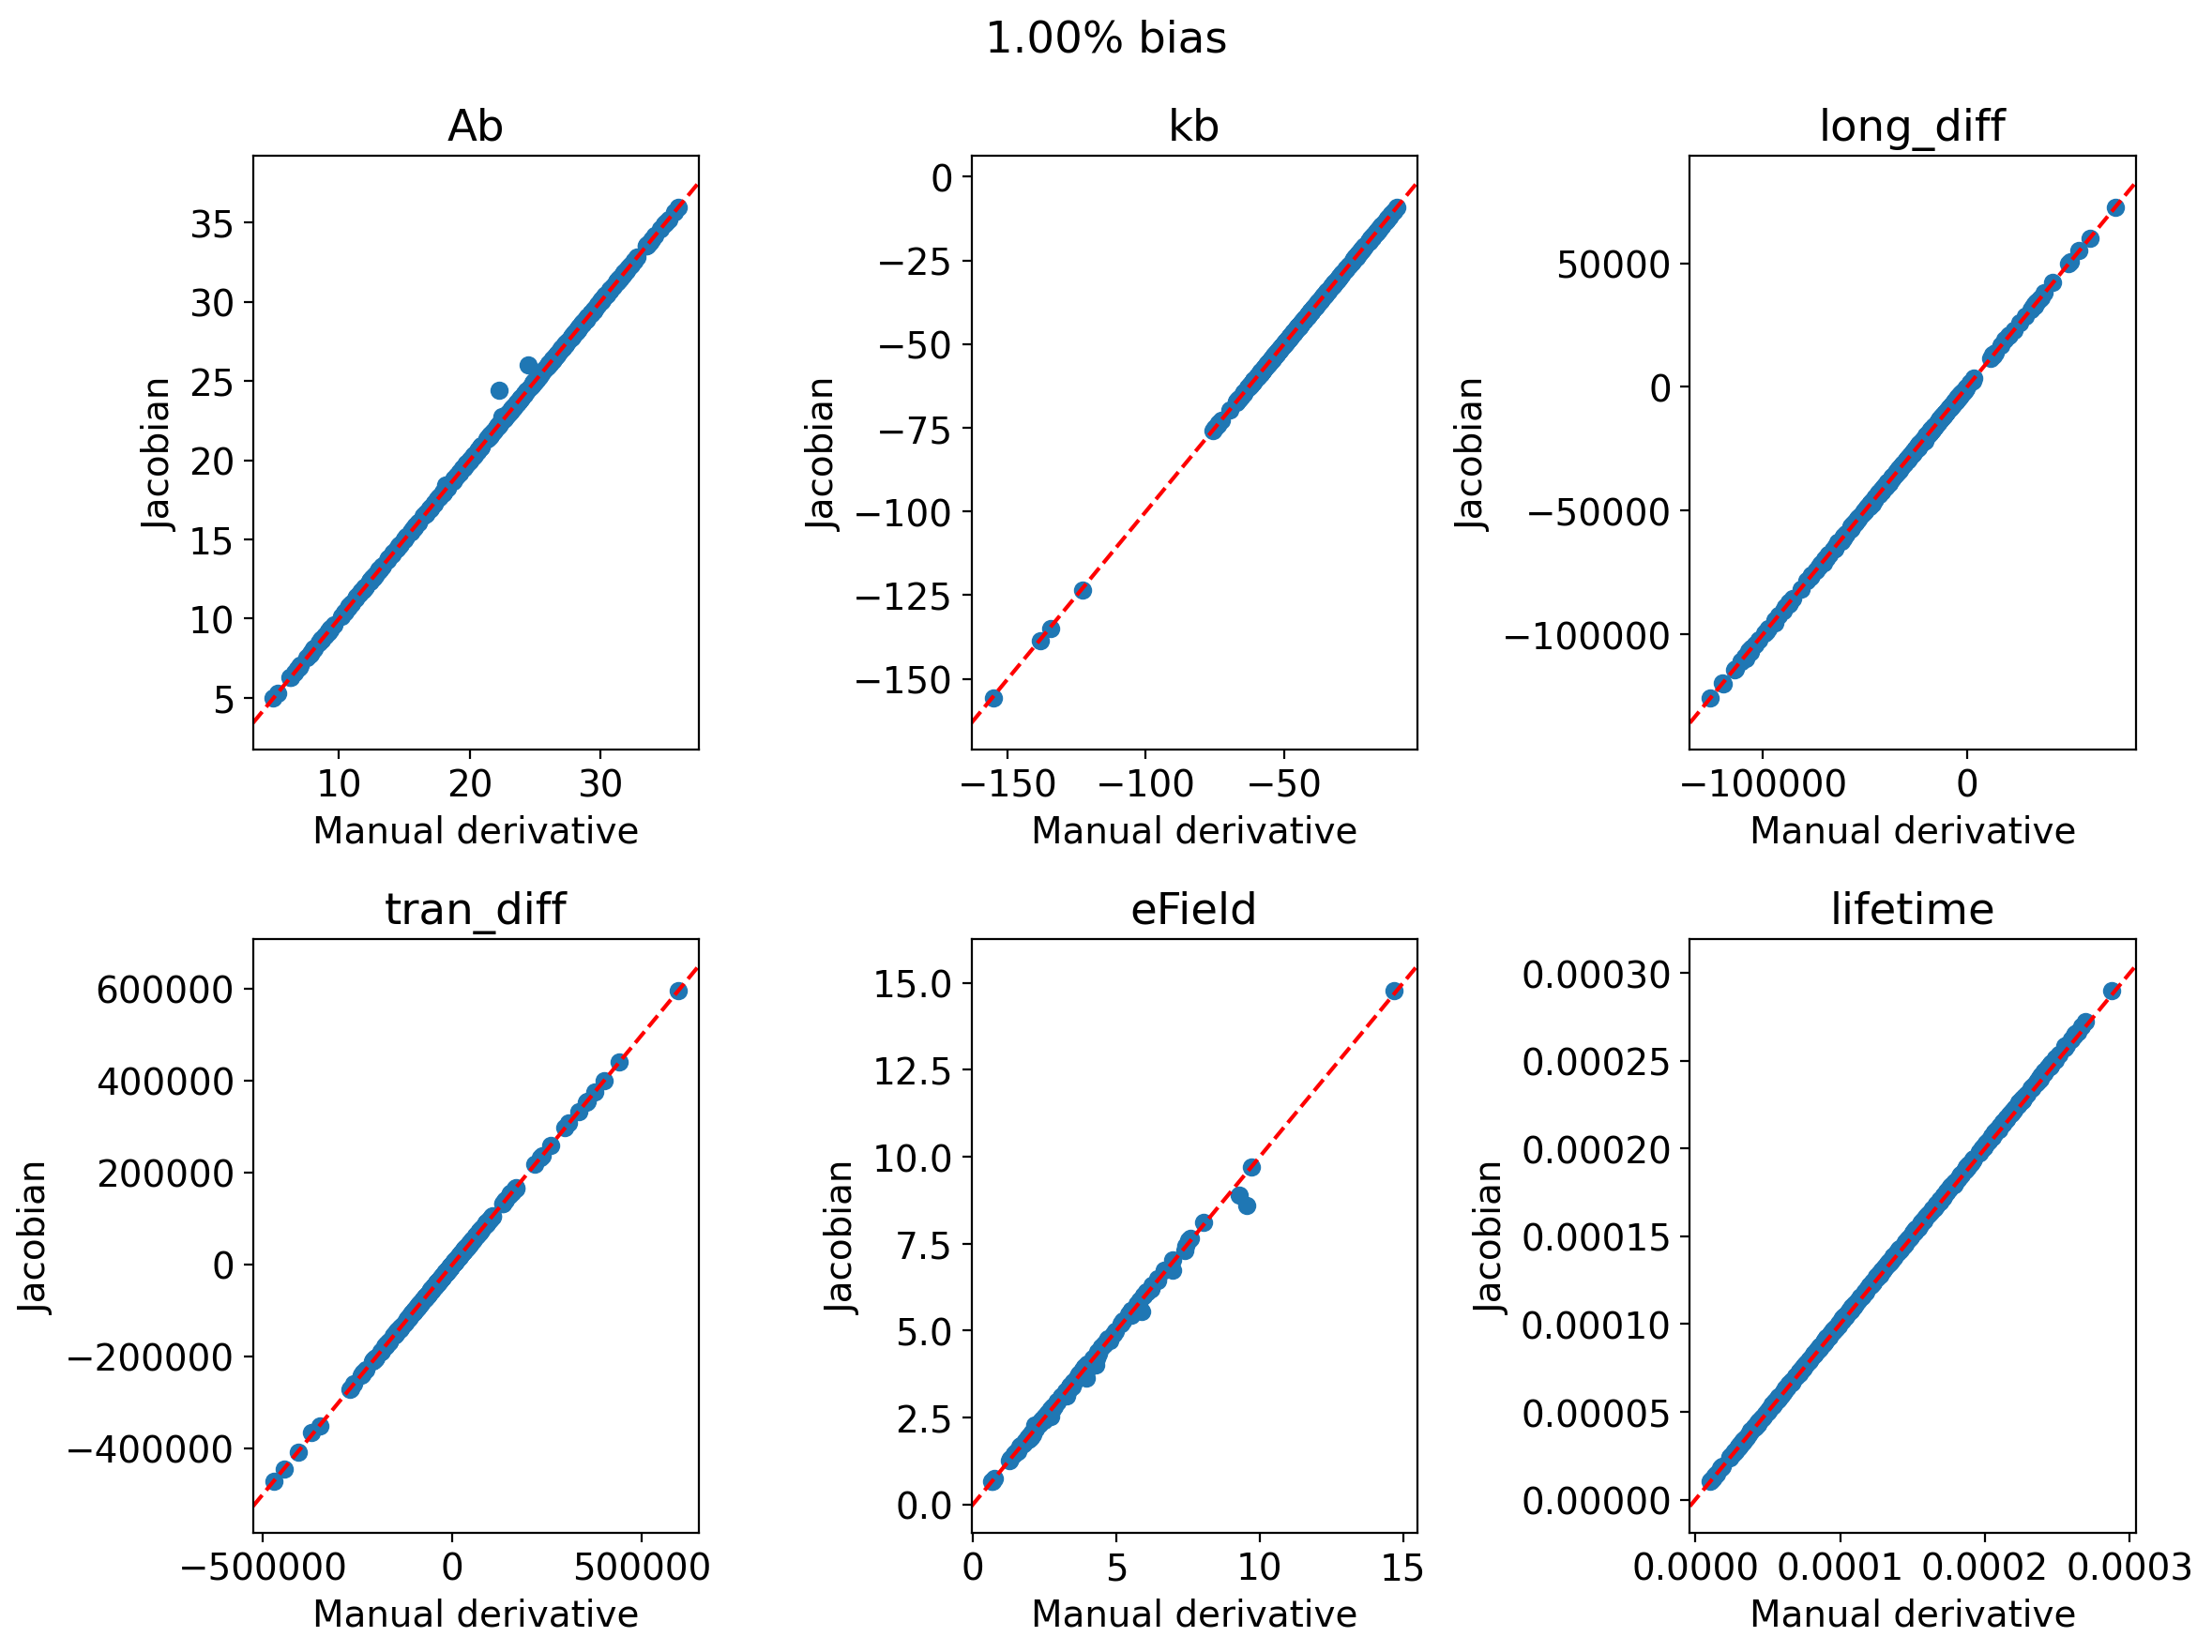

In [ ]:
import matplotlib
matplotlib.rcParams.update({'font.size': 14})

fig, axs = plt.subplots(2, 3, figsize=(12, 9))
# fig2, axs2 = plt.subplots(3, 3, figsize=(12, 12))

bias = 0.01

adcs, pixel_x, pixel_y, pixel_z, ticks, hit_prob, event, pixels = simulate_new(ref_params, response_template, tracks, fields, 0)

interesting_vars = [p for p in to_propagate if 'shift' not in p]
for i, par in enumerate(interesting_vars):
    ax = axs[i // 3, i % 3]
    ax2 = axs2[i // 3, i % 3]
    offset_pars = ref_params.replace(**{par: getattr(ref_params, par)*(1 + bias)})
    if 'shift' in par:
        offset_pars = ref_params.replace(**{par: getattr(ref_params, par) + bias})
    dx = getattr(offset_pars, par) - getattr(ref_params, par)
    offset_adcs, pixel_x, pixel_y, pixel_z, offset_ticks, hit_prob, event, offset_pixels = simulate_new(offset_pars, response_template, tracks, fields, 0)
    # offset_adcs, offset_pixels, offset_ticks, _, _, _ = simulate_parametrized(offset_pars, tracks, fields, 0, True)

    all_pixels = jnp.concatenate([pixels, offset_pixels])
    unique_pixels = jnp.sort(jnp.unique(all_pixels))

    pix_renumbering = jnp.searchsorted(unique_pixels, pixels)
    offset_pix_renumbering = jnp.searchsorted(unique_pixels, offset_pixels)

    rearranged_adcs = jnp.zeros((len(unique_pixels),), dtype=jnp.float32)
    rearranged_adcs = rearranged_adcs.at[pix_renumbering].set(adcs)
    rearranged_offset_adcs = jnp.zeros((len(unique_pixels),), dtype=jnp.float32)
    rearranged_offset_adcs = rearranged_offset_adcs.at[offset_pix_renumbering].set(offset_adcs)

    rearranged_ticks = jnp.zeros((len(unique_pixels),), dtype=jnp.float32)
    rearranged_ticks = rearranged_ticks.at[pix_renumbering].set(ticks)
    rearranged_offset_ticks = jnp.zeros((len(unique_pixels),), dtype=jnp.float32)
    rearranged_offset_ticks = rearranged_offset_ticks.at[offset_pix_renumbering].set(offset_ticks)

    rearranged_jac = jnp.zeros((len(unique_pixels), 2), dtype=jnp.float32)
    rearranged_jac = rearranged_jac.at[pix_renumbering, :].set(getattr(jac_res, par))
    
    # ax.scatter((offset_adcs.flatten() - adcs.flatten())/dx, getattr(jac_res, par).flatten())
    xpoints = (rearranged_offset_adcs[:] - rearranged_adcs[:])/dx
    ypoints = rearranged_jac[:, 0]
    ax.scatter((rearranged_offset_adcs - rearranged_adcs)/dx, rearranged_jac[:, 0])
    # ax.scatter(rearranged_adcs[:, 0], rearranged_offset_adcs[:])
    # ax2.scatter((rearranged_offset_ticks[:] - rearranged_ticks[:])/dx, rearranged_jac[:, 1])
    # ax2.scatter(rearranged_ticks[:, 0], rearranged_offset_ticks[:, 0])
    ax.set_title(par)
    ax.set_xlabel('Manual derivative')
    ax.set_ylabel('Jacobian')
    # ax2.set_title(par)
    # ax2.set_xlabel('Manual derivative')
    # ax2.set_ylabel('Jacobian')
    ymin, ymax = ax.get_ylim()
    ax.plot([ymin, ymax], [ymin, ymax], 'r--')
    ax.set_xlim(ymin, ymax)
    # ymin, ymax = ax2.get_ylim()
    # ax2.plot([ymin, ymax], [ymin, ymax], 'r--')
    # ax2.set_xlim(ymin, ymax)
    fig.suptitle(f'{bias:.2%} bias')
    

fig.tight_layout()
# fig2.tight_layout()

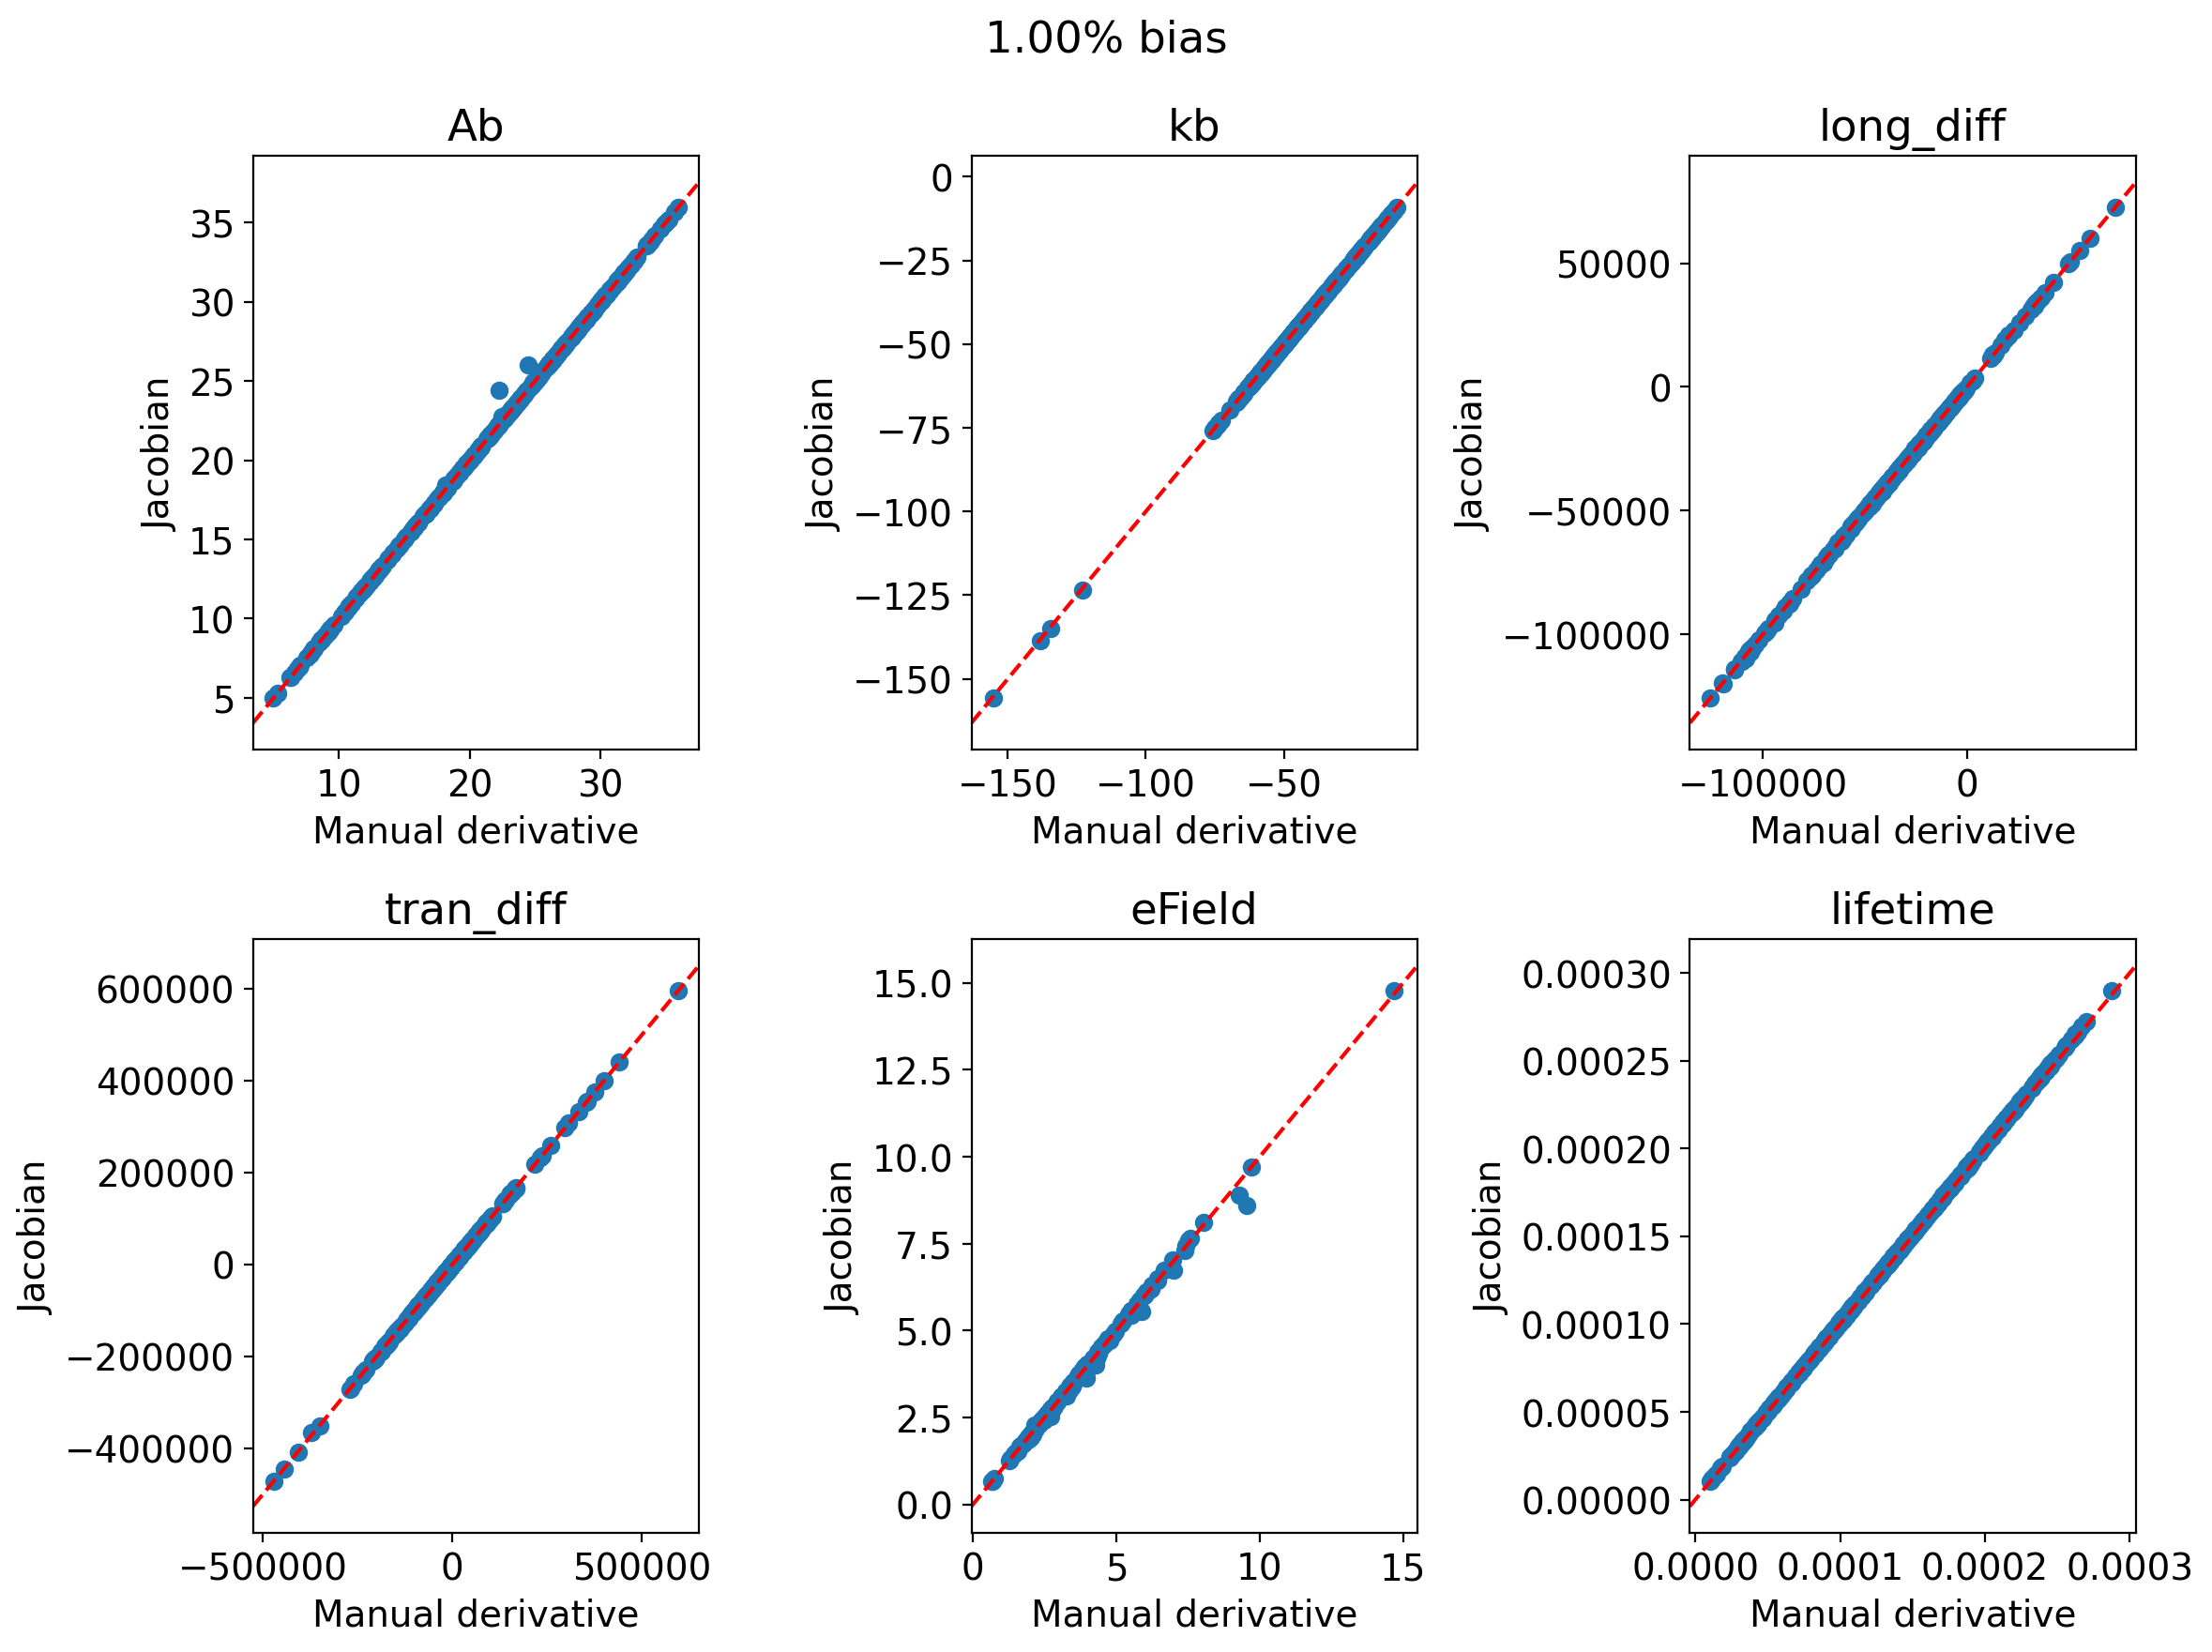

In [ ]:
import matplotlib
matplotlib.rcParams.update({'font.size': 14})

fig, axs = plt.subplots(2, 3, figsize=(12, 9))
# fig2, axs2 = plt.subplots(3, 3, figsize=(12, 12))

bias = 0.01

adcs, pixel_x, pixel_y, pixel_z, ticks, hit_prob, event, pixels = simulate_new(ref_params, response_template, tracks, fields, 0)

interesting_vars = [p for p in to_propagate if 'shift' not in p]
for i, par in enumerate(interesting_vars):
    ax = axs[i // 3, i % 3]
    # ax2 = axs2[i // 3, i % 3]
    offset_pars = ref_params.replace(**{par: getattr(ref_params, par)*(1 + bias)})
    if 'shift' in par:
        offset_pars = ref_params.replace(**{par: getattr(ref_params, par) + bias})
    dx = getattr(offset_pars, par) - getattr(ref_params, par)
    offset_adcs, pixel_x, pixel_y, pixel_z, offset_ticks, hit_prob, event, offset_pixels = simulate_new(offset_pars, response_template, tracks, fields, 0)
    # offset_adcs, offset_pixels, offset_ticks, _, _, _ = simulate_parametrized(offset_pars, tracks, fields, 0, True)

    all_pixels = jnp.concatenate([pixels, offset_pixels])
    unique_pixels = jnp.sort(jnp.unique(all_pixels))

    pix_renumbering = jnp.searchsorted(unique_pixels, pixels)
    offset_pix_renumbering = jnp.searchsorted(unique_pixels, offset_pixels)

    rearranged_adcs = jnp.zeros((len(unique_pixels),), dtype=jnp.float32)
    rearranged_adcs = rearranged_adcs.at[pix_renumbering].set(adcs)
    rearranged_offset_adcs = jnp.zeros((len(unique_pixels),), dtype=jnp.float32)
    rearranged_offset_adcs = rearranged_offset_adcs.at[offset_pix_renumbering].set(offset_adcs)

    rearranged_ticks = jnp.zeros((len(unique_pixels),), dtype=jnp.float32)
    rearranged_ticks = rearranged_ticks.at[pix_renumbering].set(ticks)
    rearranged_offset_ticks = jnp.zeros((len(unique_pixels),), dtype=jnp.float32)
    rearranged_offset_ticks = rearranged_offset_ticks.at[offset_pix_renumbering].set(offset_ticks)

    rearranged_jac = jnp.zeros((len(unique_pixels), 2), dtype=jnp.float32)
    rearranged_jac = rearranged_jac.at[pix_renumbering, :].set(getattr(jac_res, par))
    
    # ax.scatter((offset_adcs.flatten() - adcs.flatten())/dx, getattr(jac_res, par).flatten())
    xpoints = (rearranged_offset_adcs[:] - rearranged_adcs[:])/dx
    ypoints = rearranged_jac[:, 0]
    ax.scatter((rearranged_offset_adcs - rearranged_adcs)/dx, rearranged_jac[:, 0])
    # ax.scatter(rearranged_adcs[:, 0], rearranged_offset_adcs[:])
    # ax2.scatter((rearranged_offset_ticks[:] - rearranged_ticks[:])/dx, rearranged_jac[:, 1])
    # ax2.scatter(rearranged_ticks[:, 0], rearranged_offset_ticks[:, 0])
    ax.set_title(par)
    ax.set_xlabel('Manual derivative')
    ax.set_ylabel('Jacobian')
    # ax2.set_title(par)
    # ax2.set_xlabel('Manual derivative')
    # ax2.set_ylabel('Jacobian')
    ymin, ymax = ax.get_ylim()
    ax.plot([ymin, ymax], [ymin, ymax], 'r--')
    ax.set_xlim(ymin, ymax)
    # ymin, ymax = ax2.get_ylim()
    # ax2.plot([ymin, ymax], [ymin, ymax], 'r--')
    # ax2.set_xlim(ymin, ymax)
    fig.suptitle(f'{bias:.2%} bias')
    

fig.tight_layout()
# fig2.tight_layout()

In [4]:
import matplotlib
from tqdm import tqdm
matplotlib.rcParams.update({'font.size': 14})

bias = 0.0

adcs, pixel_x, pixel_y, pixel_z, ticks, hit_prob, event, pixels = simulate_new(ref_params, response_template, tracks, fields, None)

selected_pixels = pixels[500:520]
# par = 'RESET_NOISE_CHARGE'
# values = np.linspace(500, 1500, 50)
# par = 'eField'
# values = np.linspace(0.3, 0.8, 50)
par = 'Ab'
values = np.linspace(0.6, 1, 50)
# par = 'kb'
# values = np.linspace(0.04, 0.06, 50)

# to_propagate = ('Ab', 'kb', 'long_diff', 'tran_diff', 'eField', 'lifetime', 'shift_x', 'shift_y', 'shift_z')
to_propagate = (par,)
#Running some fit
Params = build_params_class(to_propagate)
ref_params = load_detector_properties(Params, "./src/larndsim/detector_properties/module0.yaml",
                                "./src/larndsim/pixel_layouts/multi_tile_layout-2.4.16_v4.yaml")
ref_params = ref_params.replace(Ab=0.8, kb=0.0486, tran_diff=4.0e-6, long_diff=8.8e-6, number_pix_neighbors=0, signal_length=100, electron_sampling_resolution=5e-3, eField=0.5, lifetime=3e3, time_padding=190)
ref_params = ref_params.replace(time_window=ref_params.signal_length)
# ref_params = ref_params.replace(RESET_NOISE_CHARGE=0., UNCORRELATED_NOISE_CHARGE=0., lifetime=1e10, long_diff=0., tran_diff=0.)
# ref_params = ref_params.replace(RESET_NOISE_CHARGE=0., UNCORRELATED_NOISE_CHARGE=0.)

response_template, ref_params = load_lut("src/larndsim/detector_properties/response_44.npy", ref_params)

adcs = np.zeros((len(selected_pixels), len(values)))
adcs_seed = np.zeros((len(selected_pixels), len(values)))
ticks = np.zeros((len(selected_pixels), len(values)))
ticks_seed = np.zeros((len(selected_pixels), len(values)))
jac_adcs = np.zeros((len(selected_pixels), len(values)))
jac_ticks = np.zeros((len(selected_pixels), len(values)))
for j, value in enumerate(tqdm(values)):
    offset_pars = ref_params.replace(**{par: value})
    offset_adcs, pixel_x, pixel_y, pixel_z, offset_ticks, hit_prob, event, offset_pixels = simulate_new(offset_pars, response_template, tracks, fields, None)
    # jac_res = jax.jacfwd(sim_wrapper)(offset_pars)
    offset_adcs_seed, _, _, pixel_z_seed, _, _, _, offset_pixels_seed = simulate_new(offset_pars, response_template, tracks, fields, 8)

    # hess_res = jax.hessian(sim_wrapper)(offset_pars)
    for i, pixid in enumerate(selected_pixels):
        idx = jnp.argwhere(offset_pixels == pixid).flatten()[0]
        adcs[i, j] = offset_adcs[idx]
        ticks[i, j] = pixel_z[idx]
        # jac_adcs[i, j] = getattr(jac_res, par)[idx, 0]
        # jac_ticks[i, j] = getattr(jac_res, par)[idx, 1]

        idx = jnp.argwhere(offset_pixels == pixid).flatten()[0]
        adcs_seed[i, j] = offset_adcs_seed[idx]
        ticks_seed[i, j] = pixel_z_seed[idx]


INFO:larndsim.consts_jax:Loading response from numpy array
100%|██████████| 50/50 [00:53<00:00,  1.08s/it]


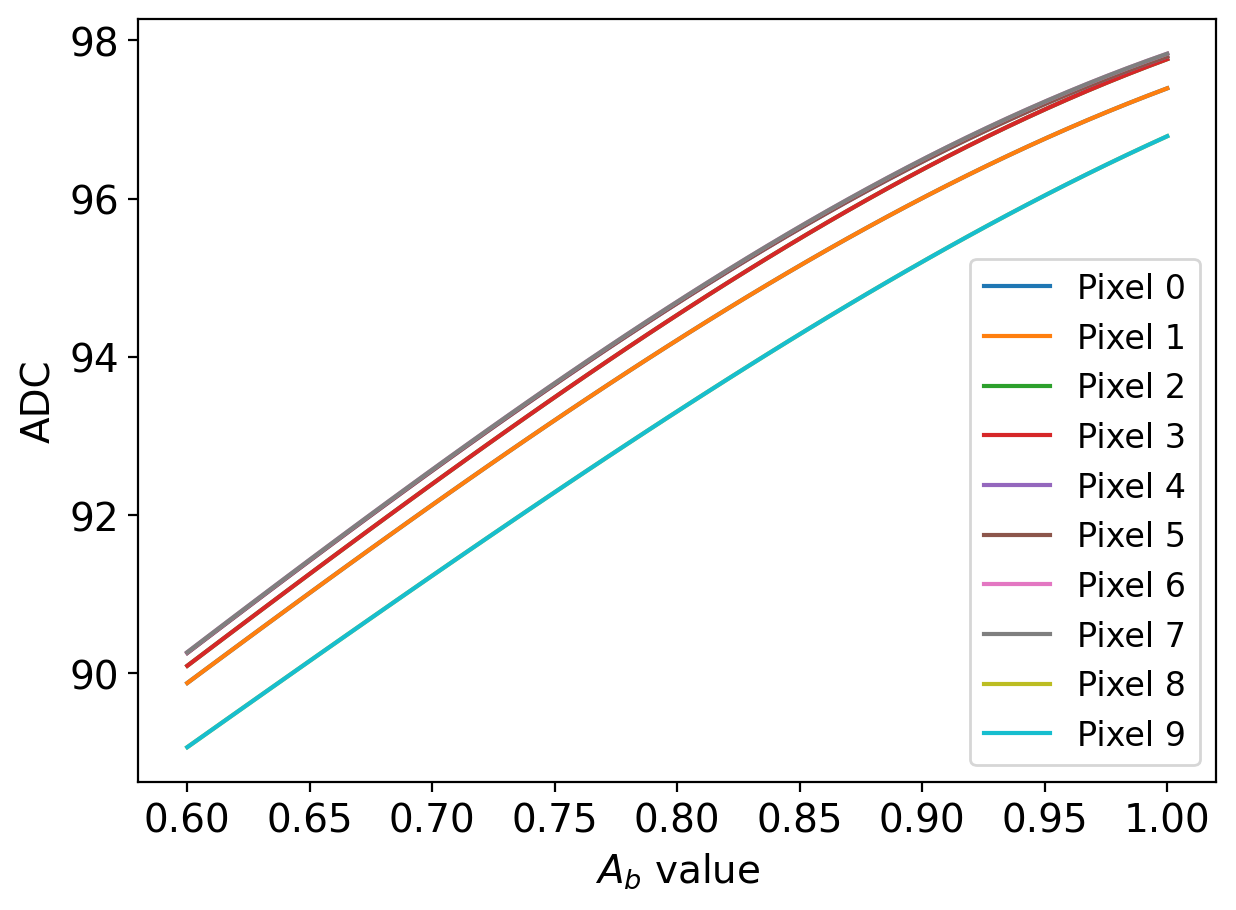

In [5]:
for i, pixid in enumerate(selected_pixels[::2]):
    plt.plot(values, adcs[i], label=f"Pixel {i}")
plt.xlabel(r'$A_b$ value')
plt.ylabel('ADC')
plt.legend(fontsize=12)
plt.tight_layout()
    # plt.scatter(values, adcs_seed[i])

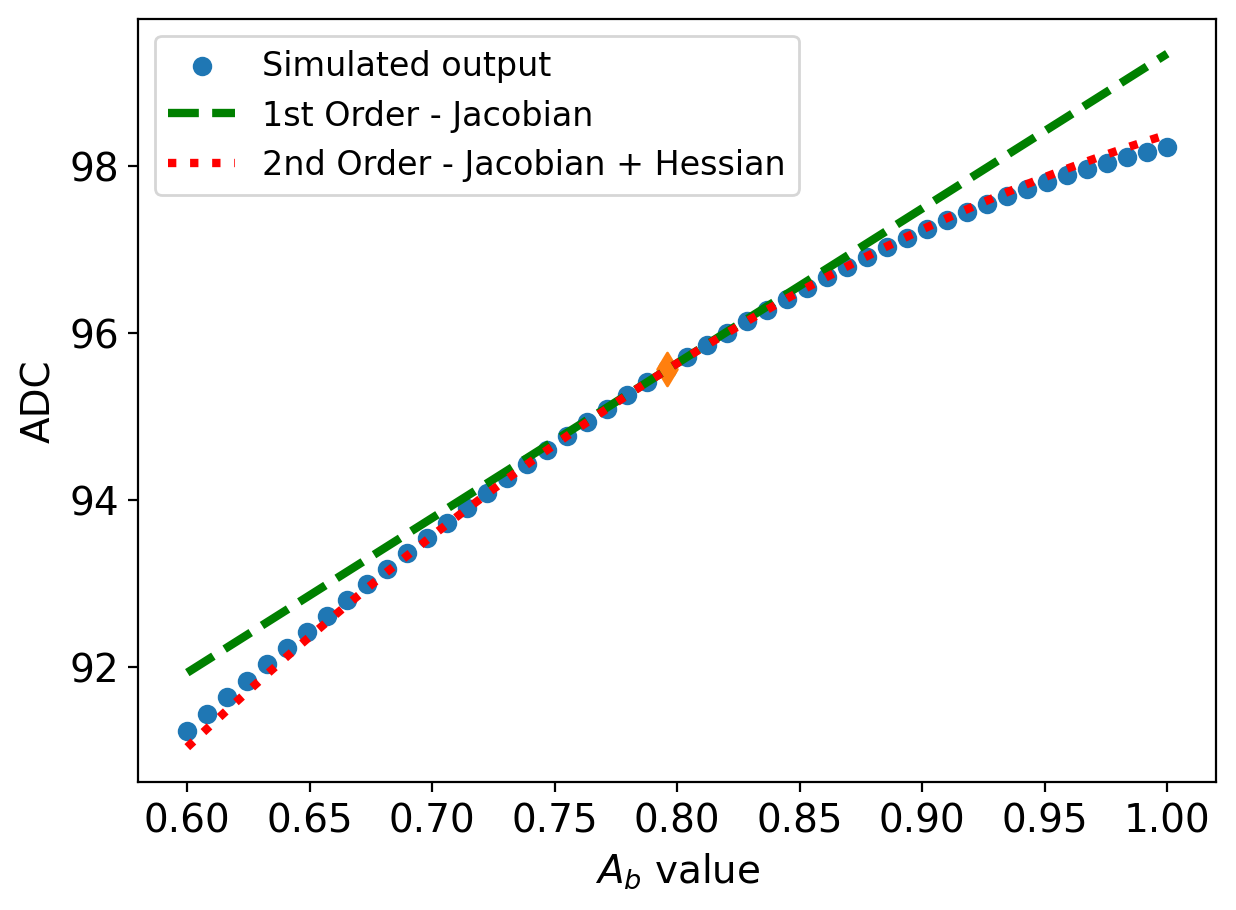

In [ ]:
#Moving to a demo of the idea of using Taylor expansions to approximate the output of the simulator around a point, and how the Jacobian and Hessian can be used for that

i = 10
mid = 24

a = values[mid]
f_a = adcs[i, mid]
f_prime_a = first_derivative_array[mid]      # f'(a)
f_double_prime_a = second_derivative_array[mid] # f''(a)

# 2. CALCULATE TAYLOR EXPANSIONS
dx = values - a  # This is the (x - a) term

# 1st-Order (Linear) Estimate
y_linear = f_a + f_prime_a * dx

# 2nd-Order (Quadratic) Estimate
# We can build on the linear one
y_quadratic = y_linear + (f_double_prime_a / 2.0) * (dx**2)

plt.scatter(values, adcs[i], label=f"Simulated output")
plt.scatter(a, f_a, marker='d', s=70)
plt.plot(values, y_linear, 'g--', linewidth=3, label="1st Order - Jacobian")
plt.plot(values, y_quadratic, 'r:', linewidth=3, label="2nd Order - Jacobian + Hessian")
plt.xlabel(r'$A_b$ value')
plt.ylabel('ADC')
plt.legend(fontsize=12)
plt.tight_layout()
    # plt.scatter(values, adcs_seed[i])

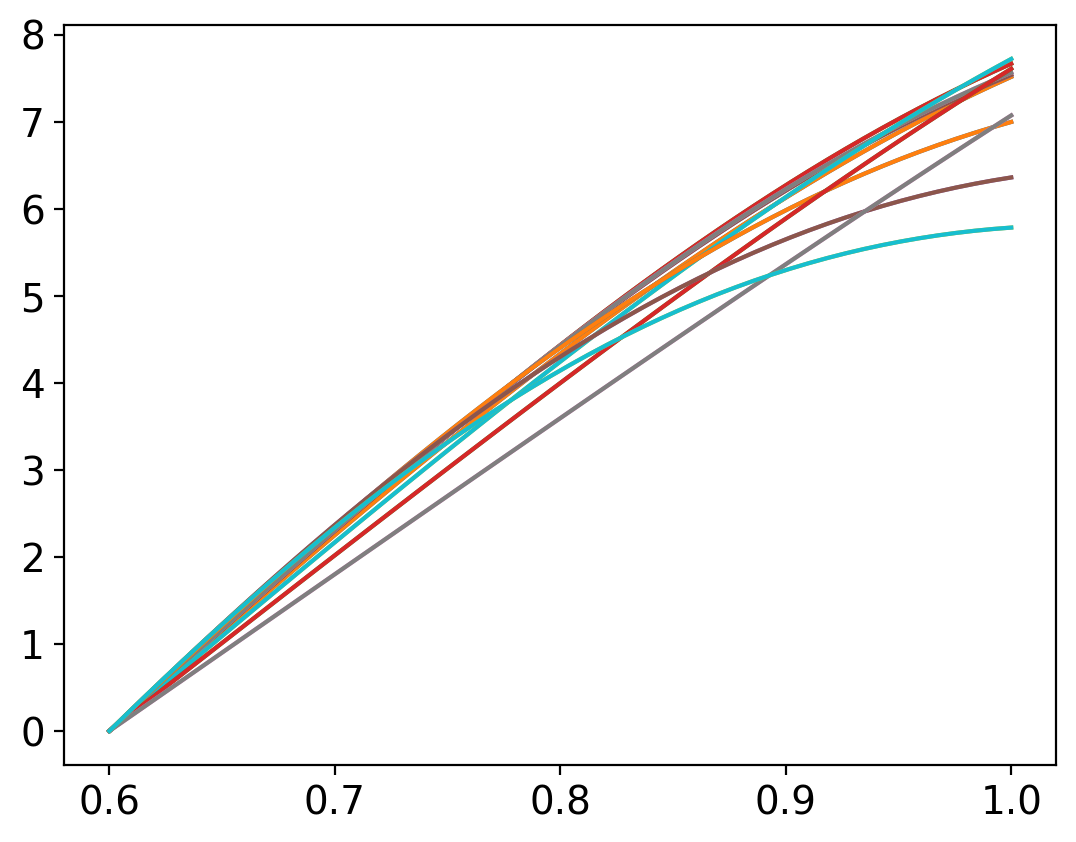

In [48]:
for i, pixid in enumerate(selected_pixels):
    plt.plot(values, adcs[i] - adcs[i][0])
    # plt.scatter(values, jac_adcs[i])

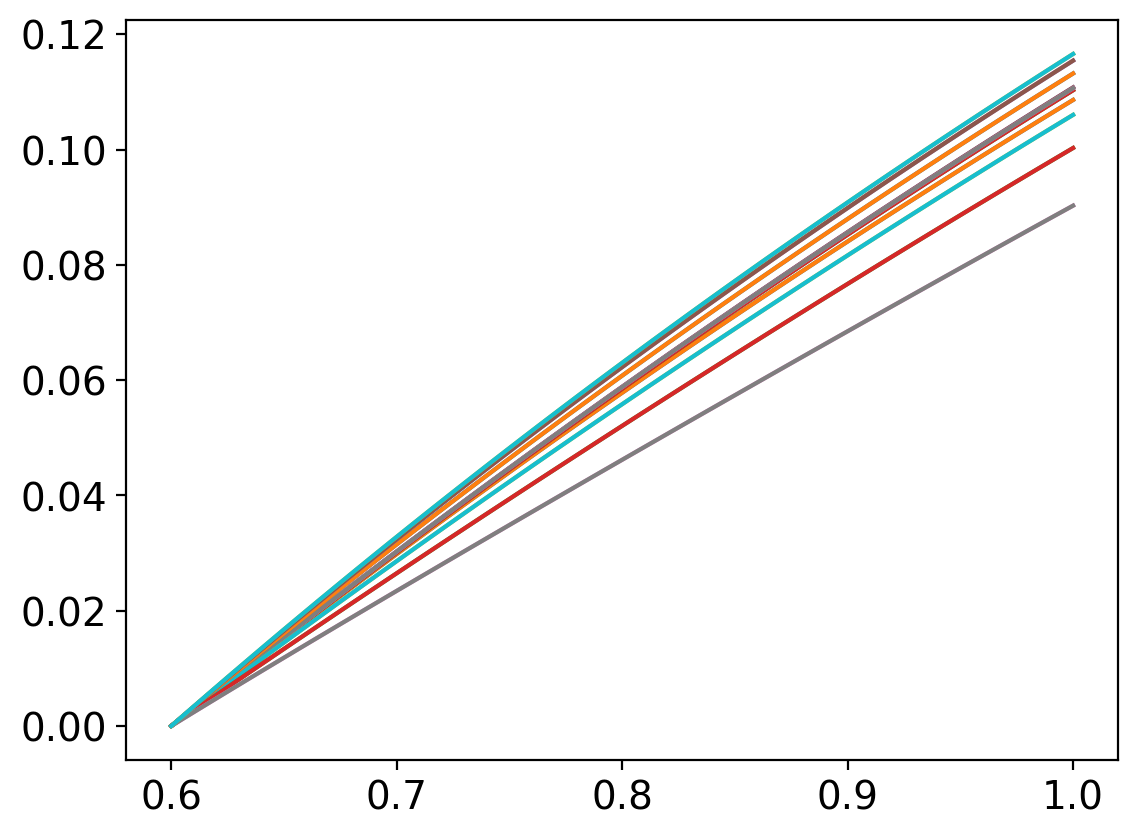

In [49]:
for i, pixid in enumerate(selected_pixels):
    plt.plot(values, ticks[i] - ticks[i][0])
    # plt.scatter(values, jac_adcs[i])

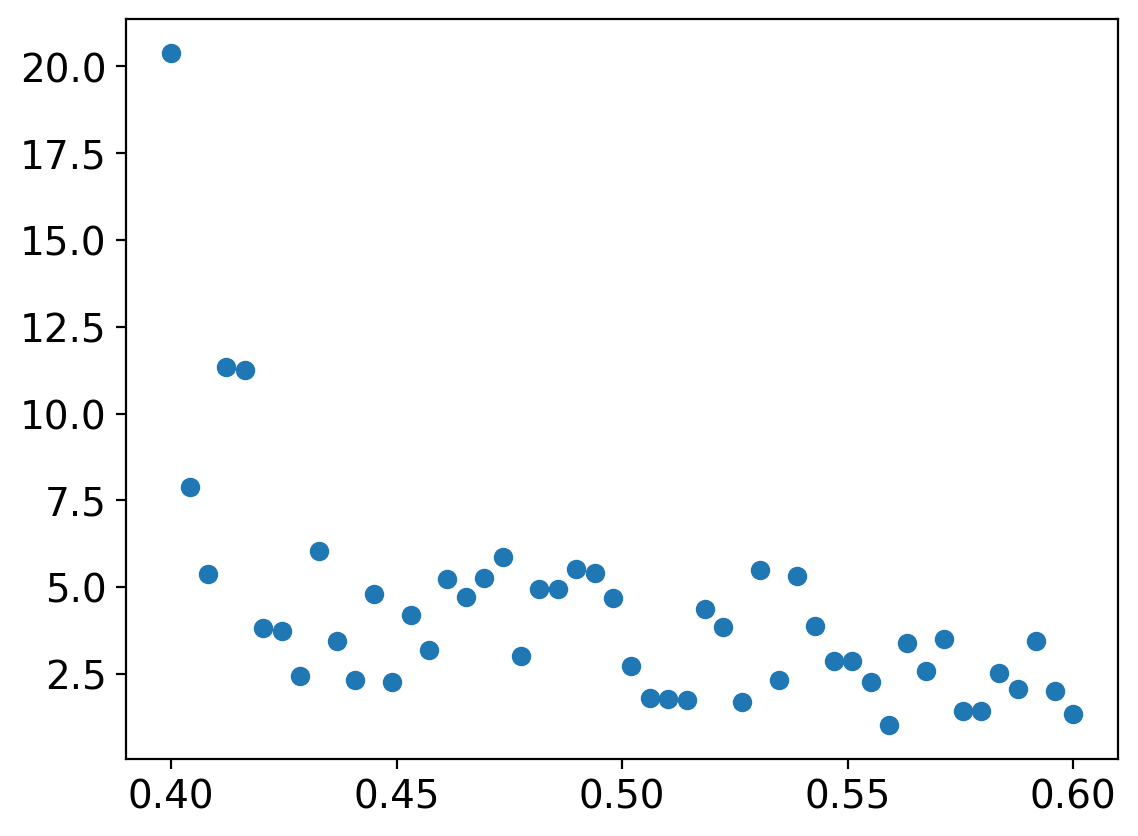

In [11]:
plt.scatter(values, jac_adcs[2])

In [12]:
jac_adcs

array([[ 5.51366138,  6.79151392,  4.05564308, 20.38360214, 20.24114609,
         5.02762127,  3.73957515,  8.02093983,  2.40744376,  3.54759312,
         7.49738264,  3.25266314,  7.31457996,  5.23752308,  3.25734687,
         2.14486051,  6.18952799,  2.07765841,  5.18576145,  3.86853456,
         1.98362064,  1.95350599,  4.76728392,  4.82004642,  1.86730218,
         3.57683182,  6.01184368,  5.89802265,  5.82671499,  1.73649311,
         2.65532088,  5.49413061,  5.99606371,  2.4397471 ,  5.9693532 ,
         1.06362593,  3.7157259 ,  3.73833323,  2.8949244 ,  3.72409606,
         2.24189353,  3.54020071,  0.95042533,  4.66538191,  4.65336847,
         3.37922502,  2.43328953,  1.36502111,  2.39933038,  4.3438735 ],
       [ 5.51366138,  6.79151392,  4.05564308, 20.38360214, 20.24114609,
         5.02762127,  3.73957515,  8.02093983,  2.40744376,  3.54759312,
         7.49738264,  3.25266314,  7.31457996,  5.23752308,  3.25734687,
         2.14486051,  6.18952799,  2.07765841,  5.